# 08 · Robust Model Evaluation and Feature Importance

Notebook 07 scores each model on one test split of **18 launches**. On a sample that small, each prediction moves accuracy by about 5.6 points, so the model ranking can change completely with a different random split.

This notebook goes beyond the course material:

1. **Repeated stratified cross-validation** (5 folds × 20 repeats = 100 fits per model) gives a mean accuracy with a spread instead of a single number.
2. **Ensemble models** (random forest and gradient boosting) are compared against the four course models.
3. **Scaling runs inside a `Pipeline`**, so no test-fold information leaks into training.
4. **Feature importance** shows which features actually drive the predictions.
5. **A baseline** (always predict "landed") shows how much the models really add.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
X = pd.read_csv("../data/dataset_part_3.csv")
y = pd.read_csv("../data/dataset_part_2.csv")["Class"]
print(f"{X.shape[0]} launches, {X.shape[1]} features, {y.mean():.0%} landed")

90 launches, 83 features, 67% landed


## Models

The hyperparameters come from the grid searches in notebook 07. Every model is scaled inside its own pipeline.

In [2]:
models = {
    "Baseline (always 'landed')": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(C=0.01, max_iter=1000),
    "SVM": SVC(C=1.0, gamma=0.0316, kernel="sigmoid"),
    "KNN": KNeighborsClassifier(n_neighbors=10, p=1),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05, random_state=RANDOM_STATE),
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=RANDOM_STATE)
rows, fold_scores = [], {}
for name, model in models.items():
    scores = cross_validate(make_pipeline(StandardScaler(), model), X, y, cv=cv,
                            scoring=["accuracy", "f1", "roc_auc"], n_jobs=-1)
    fold_scores[name] = scores["test_accuracy"]
    rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy std": scores["test_accuracy"].std(),
        "F1": scores["test_f1"].mean(),
        "ROC AUC": scores["test_roc_auc"].mean(),
    })

results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results.style.format({c: "{:.3f}" for c in results.columns if c != "Model"})

,Model,Accuracy,Accuracy std,F1,ROC AUC
0,KNN,0.845,0.073,0.893,0.844
1,SVM,0.844,0.075,0.890,0.896
2,Random Forest,0.837,0.071,0.884,0.875
3,Decision Tree,0.828,0.087,0.870,0.814
4,Logistic Regression,0.826,0.069,0.884,0.858
5,Gradient Boosting,0.823,0.070,0.872,0.861
6,Baseline (always 'landed'),0.667,0.000,0.800,0.500


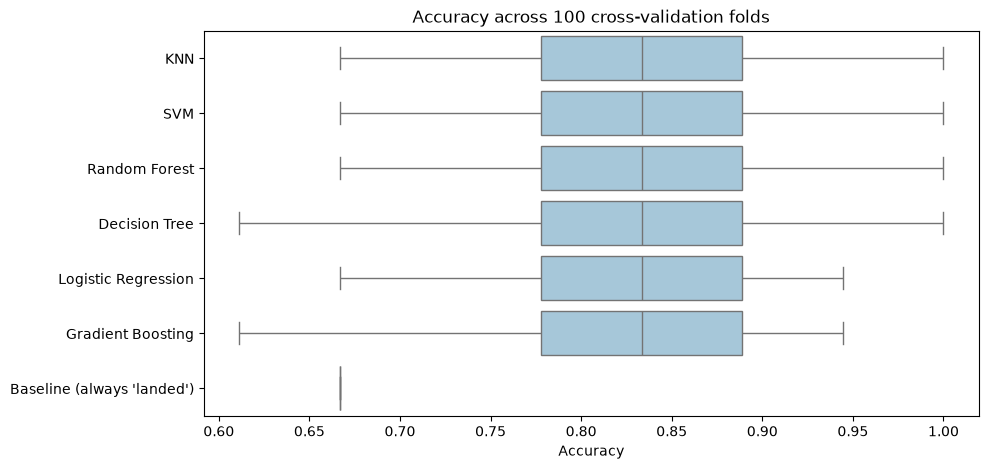

In [3]:
order = results["Model"].tolist()
long = pd.DataFrame([(m, s) for m in order for s in fold_scores[m]], columns=["Model", "Accuracy"])

plt.figure(figsize=(10, 5))
sns.boxplot(data=long, y="Model", x="Accuracy", order=order, color="#9ecae1")
plt.title("Accuracy across 100 cross-validation folds")
plt.xlabel("Accuracy")
plt.ylabel("")
plt.savefig("../images/cv_accuracy_distribution.png", bbox_inches="tight", dpi=120)
plt.show()

## Which features matter?

A random forest fit on all 90 launches. Its impurity-based importances are summed per original feature, so the one-hot columns (every orbit, site, landing pad and booster serial, plus the True/False flags) count as one feature each. Permutation importance is not used here: with so few test launches and many correlated one-hot columns, it returns near-zero scores for almost everything.

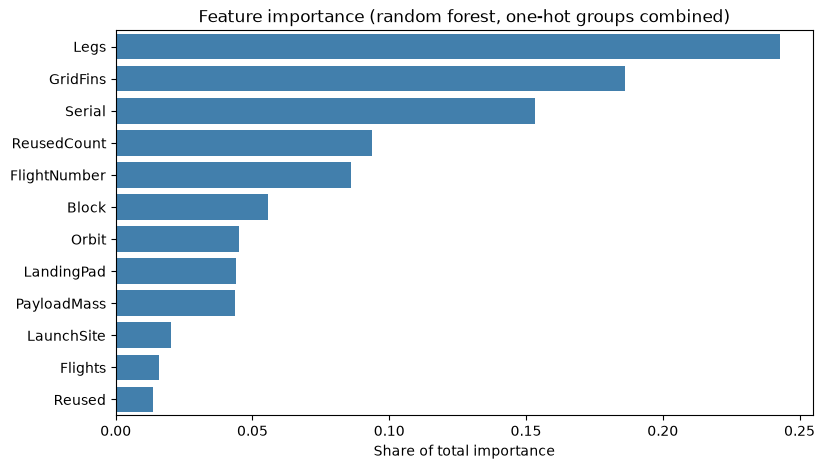

Legs            0.243
GridFins        0.186
Serial          0.153
ReusedCount     0.094
FlightNumber    0.086
Block           0.056
Orbit           0.045
LandingPad      0.044
PayloadMass     0.044
LaunchSite      0.020
Flights         0.016
Reused          0.014
dtype: float64

In [4]:
rf = RandomForestClassifier(n_estimators=500, max_depth=6, random_state=RANDOM_STATE).fit(X, y)
groups = (X.columns.str.replace(r"^(Orbit|LaunchSite|LandingPad|Serial)_.*", r"\1", regex=True)
          .str.replace(r"_(True|False)$", "", regex=True))
importance = pd.Series(rf.feature_importances_, index=X.columns).groupby(groups).sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importance.values, y=importance.index, color="#3182bd")
plt.title("Feature importance (random forest, one-hot groups combined)")
plt.xlabel("Share of total importance")
plt.ylabel("")
plt.savefig("../images/feature_importance.png", bbox_inches="tight", dpi=120)
plt.show()
importance.round(3)

## Conclusions

- The baseline already scores about **67%**, because two-thirds of the launches landed. The real question is how far each model gets beyond that.
- Across 100 folds, the models sit within a few points of each other and their spreads overlap heavily. The ranking in notebook 07, which comes from one 18-launch test split, is mostly noise.
- **Landing hardware and booster history carry most of the signal.** Whether the booster had landing legs and grid fins, which specific booster (serial) flew, and how often it had been reused together account for most of the importance. Flight number adds more: SpaceX simply got better at landing over time.
- Orbit, payload mass and launch site add smaller effects. Launch site matters less once booster history is known.
- To improve the model meaningfully, the next step is **more data** (the SpaceX API now has hundreds more launches) rather than more tuning.